# Exploratory Data Analysis — YouTube Toxic Comments

## Objetivo

Este notebook realiza el análisis exploratorio del dataset de comentarios de YouTube con el objetivo de:

- comprender la estructura y características de los datos;
- evaluar su calidad;
- estudiar la distribución de las etiquetas;
- analizar las relaciones entre las distintas categorías de toxicidad;
- explorar las características de los textos y su distribución por vídeo;
- identificar problemas, limitaciones o desbalances que puedan afectar al posterior preprocesamiento y modelado.

El análisis se realiza inicialmente sobre los datos raw y el EDA no debe modificar el dataset original.

# 1. Objetivo y alcance

Realizaremos un análisis exploratorio del dataset de comentarios de YouTube para comprender su estructura, calidad y características. Posteriormente estudiaremos las etiquetas, el contenido de los textos y la distribución de los comentarios entre vídeos.

Los resultados servirán para fundamentar las decisiones posteriores de preprocesamiento y modelado. El análisis parte del dataset raw y el EDA no modificará el dataset original.

In [7]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/raw/youtoxic_english_1000 (1).csv")

df = pd.read_csv(data_path, encoding="utf-8-sig")

print(f"Dataset cargado correctamente: {type(df).__name__}")

Dataset cargado correctamente: DataFrame


## 2. Comprensión inicial del dataset

### 2.1 Dimensiones y estructura

Antes de analizar la calidad de los datos o las etiquetas, comprobamos el tamaño y la estructura general del dataset. Esto permite conocer cuántos comentarios y variables están disponibles para el análisis.

In [8]:
n_rows, n_columns = df.shape

print(f"Número de registros: {n_rows}")
print(f"Número de variables: {n_columns}")
print("\nColumnas del dataset:")

for column in df.columns:
    print(f"- {column}")

Número de registros: 1000
Número de variables: 15

Columnas del dataset:
- CommentId
- VideoId
- Text
- IsToxic
- IsAbusive
- IsThreat
- IsProvocative
- IsObscene
- IsHatespeech
- IsRacist
- IsNationalist
- IsSexist
- IsHomophobic
- IsReligiousHate
- IsRadicalism


### Interpretación

**Hechos observados**

El dataset contiene 1.000 registros y 15 variables. Entre las columnas se encuentran dos identificadores (`CommentId` y `VideoId`), una variable de texto (`Text`) y doce variables cuyos nombres comienzan por `Is`, entre ellas `IsToxic`.

**Interpretación**

La estructura observada permite distinguir inicialmente entre información de identificación, contenido textual y variables asociadas a distintas categorías de etiquetado. Dado que la solución de triaje utiliza `IsToxic` como referencia inicial de toxicidad, será necesario analizar posteriormente su distribución y su relación con las etiquetas secundarias.

En esta etapa no se puede determinar todavía cómo fueron construidas las etiquetas ni si `IsToxic` deriva de alguna combinación de las demás variables.

### 2.2 Tipos de datos y cardinalidad

Analizamos los tipos de datos y el número de valores únicos de cada variable para comprobar cómo se han interpretado durante la carga e identificar posibles identificadores, variables de agrupación y etiquetas de baja cardinalidad.

In [9]:
column_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "valores_unicos": df.nunique(dropna=False)
})

column_summary

,dtype,valores_unicos
CommentId,str,1000
VideoId,str,13
Text,str,997
IsToxic,bool,2
IsAbusive,bool,2
IsThreat,bool,2
IsProvocative,bool,2
IsObscene,bool,2
IsHatespeech,bool,2
IsRacist,bool,2


### Conclusiones

**Hechos observados**

- `CommentId` es de tipo texto y presenta 1.000 valores únicos para 1.000 registros.
- `VideoId` es de tipo texto y contiene 13 valores únicos.
- `Text` es de tipo texto y presenta 997 valores únicos.
- Las doce variables cuyo nombre comienza por `Is` han sido interpretadas como booleanas.
- Diez de estas variables presentan dos valores posibles en los datos, mientras que `IsHomophobic` e `IsRadicalism` presentan un único valor observado.

**Interpretación**

La cardinalidad de `CommentId` es consistente con su función como identificador único de cada registro. Por su parte, los 13 valores de `VideoId` muestran que los comentarios están distribuidos entre un conjunto reducido de vídeos, aspecto que deberá analizarse posteriormente por sus posibles implicaciones en la evaluación.

La existencia de 997 textos únicos frente a 1.000 registros indica que hay textos repetidos. En esta etapa no se determina todavía si corresponden a duplicados completos o a comentarios distintos con el mismo contenido; esto se comprobará en el análisis de calidad de datos.

Las variables `Is...` presentan una estructura booleana coherente con variables de etiquetado. Sin embargo, todavía no se ha analizado su distribución ni la relación entre `IsToxic` y las etiquetas secundarias. El hecho de que `IsHomophobic` e `IsRadicalism` tengan un único valor observado indica ausencia de variabilidad en estas variables dentro del dataset, pero será necesario comprobar cuál es ese valor antes de extraer conclusiones sobre su cobertura.

## 3. Calidad de los datos

Antes de analizar `IsToxic` y las etiquetas secundarias, evaluamos la calidad del dataset para detectar problemas que puedan afectar al análisis y, posteriormente, al desarrollo y evaluación del sistema de triaje.

Se revisarán valores ausentes, duplicados, consistencia de identificadores y etiquetas, y algunos aspectos básicos de calidad del texto. En esta fase únicamente se detectan y documentan posibles problemas; no se modifica el dataset raw.

In [10]:
missing_summary = pd.DataFrame({
    "ausentes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
})

missing_summary

,ausentes,porcentaje
CommentId,0,0.0
VideoId,0,0.0
Text,0,0.0
IsToxic,0,0.0
IsAbusive,0,0.0
IsThreat,0,0.0
IsProvocative,0,0.0
IsObscene,0,0.0
IsHatespeech,0,0.0
IsRacist,0,0.0


In [11]:
text_check = df["Text"].astype("string")

empty_texts = text_check.eq("").sum()
whitespace_texts = text_check.str.fullmatch(r"\s*", na=False).sum()

missing_markers = {"null", "none", "nan", "na", "n/a"}

textual_missing = (
    text_check
    .str.strip()
    .str.lower()
    .isin(missing_markers)
    .sum()
)

print(f"Textos vacíos: {empty_texts}")
print(f"Textos formados solo por espacios: {whitespace_texts}")
print(f"Representaciones textuales de ausencia: {textual_missing}")

Textos vacíos: 0
Textos formados solo por espacios: 0
Representaciones textuales de ausencia: 0


### Conclusiones

**Hechos observados**

No se detectan valores ausentes reconocidos por pandas en ninguna de las 15 variables del dataset. Todas las columnas presentan un 0 % de valores ausentes.

En `Text` tampoco se detectan cadenas vacías, textos formados únicamente por espacios ni las representaciones textuales de ausencia comprobadas (`null`, `none`, `nan`, `na` y `n/a`).

**Interpretación**

Para los criterios evaluados, el dataset presenta una buena completitud: los 1.000 registros contienen información en todas las variables y no se han identificado comentarios sin contenido textual utilizable.

Este resultado se refiere únicamente a la presencia de datos. No permite concluir todavía que los valores sean correctos, únicos o consistentes, aspectos que se analizan a continuación.

### 3.2 Duplicados

Analizamos la presencia de filas completamente duplicadas y posibles duplicados en `CommentId` y `Text`.

Esta comprobación permite distinguir entre registros repetidos, problemas potenciales de identificación y comentarios distintos que comparten exactamente el mismo texto. Estos casos pueden ser relevantes posteriormente para evitar sesgos o fuga de información durante la evaluación.

In [12]:
full_duplicates = df.duplicated().sum()
duplicate_comment_ids = df["CommentId"].duplicated().sum()

duplicate_text_mask = df["Text"].duplicated(keep=False)
duplicate_text_records = duplicate_text_mask.sum()
duplicate_text_values = df.loc[duplicate_text_mask, "Text"].nunique()

print(f"Filas completamente duplicadas: {full_duplicates}")
print(f"CommentId duplicados: {duplicate_comment_ids}")
print(f"Textos distintos que aparecen más de una vez: {duplicate_text_values}")
print(f"Registros afectados por textos repetidos: {duplicate_text_records}")

Filas completamente duplicadas: 0
CommentId duplicados: 0
Textos distintos que aparecen más de una vez: 2
Registros afectados por textos repetidos: 5


In [13]:
duplicate_text_analysis = (
    df.loc[duplicate_text_mask]
    .groupby("Text")
    .agg(
        apariciones=("CommentId", "size"),
        comment_ids=("CommentId", "nunique"),
        videos=("VideoId", "nunique")
    )
    .reset_index(drop=True)
)

duplicate_text_analysis

,apariciones,comment_ids,videos
0,2,2,1
1,3,3,1


### Conclusiones

**Hechos observados**

No se detectan filas completamente duplicadas ni valores duplicados de `CommentId`. Cada uno de los 1.000 registros mantiene, por tanto, un identificador diferente.

Se identifican dos textos distintos que aparecen repetidos y afectan en conjunto a cinco registros. Uno de estos textos aparece en dos registros y el otro en tres. En todos los casos, las repeticiones corresponden a `CommentId` diferentes y se producen dentro del mismo `VideoId`.

**Interpretación**

Los textos repetidos no constituyen duplicados completos del dataset, ya que corresponden a registros con identificadores diferentes. Su presencia puede representar comentarios distintos con exactamente el mismo contenido dentro de un mismo vídeo.

No se eliminan estos registros durante el EDA. Sin embargo, deberán tenerse en cuenta al definir posteriormente la estrategia de partición y evaluación, ya que textos idénticos distribuidos entre conjuntos de entrenamiento y evaluación podrían producir fuga de información y una estimación demasiado optimista del rendimiento.

### 3.3 Consistencia de identificadores

Comprobamos la estructura de `CommentId` y `VideoId` para verificar su consistencia como identificadores y conocer cómo se distribuyen los comentarios entre los vídeos disponibles.

Esta revisión es relevante porque `CommentId` identifica cada registro, mientras que `VideoId` puede representar una estructura de agrupación que deberá considerarse posteriormente durante la evaluación.

In [14]:
identifier_summary = pd.DataFrame({
    "registros": [len(df), len(df)],
    "valores_unicos": [
        df["CommentId"].nunique(),
        df["VideoId"].nunique()
    ],
    "ausentes": [
        df["CommentId"].isna().sum(),
        df["VideoId"].isna().sum()
    ]
}, index=["CommentId", "VideoId"])

identifier_summary

,registros,valores_unicos,ausentes
CommentId,1000,1000,0
VideoId,1000,13,0


In [15]:
comments_per_video = (
    df.groupby("VideoId")
    .size()
    .sort_values(ascending=False)
    .rename("numero_comentarios")
)

comments_per_video

VideoId
9pr1oE34bIM    274
04kJtp6pVXI    172
cT14IbTDW2c    146
dG7mZQvaQDk    112
TZxEyoplYbI    104
bUgKZMSxr3E     39
8HB18hZrhXc     38
4rCweDxDqdw     37
Dt9-byUhPdg     34
#NAME?          16
XRuCW80L9mA     10
dDbRyFIkNII     10
5vF4si3hoRA      8
Name: numero_comentarios, dtype: int64

### Conclusiones

**Hechos observados**

`CommentId` presenta 1.000 valores únicos para los 1.000 registros y no contiene valores ausentes, lo que es consistente con su función como identificador único.

`VideoId` tampoco presenta valores ausentes y contiene 13 valores distintos. La distribución de comentarios entre vídeos no es uniforme: los cinco `VideoId` con mayor número de registros concentran 808 de los 1.000 comentarios (80,8 % del dataset).

Además, entre los valores de `VideoId` aparece `#NAME?`, con 16 registros.

**Interpretación**

Los comentarios están concentrados en un número reducido de vídeos, por lo que las observaciones no deben considerarse automáticamente independientes respecto a su vídeo de origen. Esta estructura deberá estudiarse posteriormente al diseñar la estrategia de partición y evaluación del sistema.

El valor `#NAME?` requiere una comprobación adicional antes de determinar si corresponde a un identificador válido del dataset o a una anomalía en los datos. No se modifica ni elimina durante el EDA.

#### Revisión de un valor atípico en `VideoId`

Durante el análisis se observa el valor `#NAME?` en 16 registros. Se comprueba su estructura para documentar el caso sin asumir previamente que se trate de un error.

In [16]:
name_records = df.loc[df["VideoId"].eq("#NAME?")]

print(f"Registros con VideoId '#NAME?': {len(name_records)}")
print(f"CommentId únicos: {name_records['CommentId'].nunique()}")
print(f"Textos únicos: {name_records['Text'].nunique()}")
print(f"Valores ausentes en esos registros: {name_records.isna().sum().sum()}")

Registros con VideoId '#NAME?': 16
CommentId únicos: 16
Textos únicos: 16
Valores ausentes en esos registros: 0


#### Conclusión sobre `VideoId = "#NAME?"`

**Hechos observados**

El valor `#NAME?` aparece como `VideoId` en 16 registros. Los 16 registros tienen `CommentId` diferentes, contienen 16 textos distintos y no presentan valores ausentes.

**Interpretación**

Los registros asociados a `#NAME?` contienen información completa y corresponden a comentarios diferentes, por lo que no existe evidencia suficiente para descartarlos como registros inválidos.

Sin embargo, `#NAME?` presenta un formato diferente al resto de los identificadores de vídeo observados y podría representar una anomalía en el campo `VideoId`. Al no disponer de información sobre el proceso de extracción o construcción del dataset, no es posible determinar su origen únicamente mediante este EDA.

Por este motivo, los registros se mantienen sin modificaciones y el caso queda documentado para su revisión antes de definir la estrategia definitiva de preprocesamiento y evaluación.

### 3.4 Consistencia de las etiquetas

Antes de estudiar la distribución de `IsToxic` y de las etiquetas secundarias, comprobamos que las variables de etiquetado presenten valores y tipos consistentes.

El objetivo es verificar qué valores booleanos aparecen realmente en cada etiqueta y detectar categorías sin variabilidad o posibles valores inesperados. Esta comprobación permite conocer la cobertura disponible sin asumir todavía cómo se relacionan las distintas etiquetas.

In [17]:
label_columns = [column for column in df.columns if column.startswith("Is")]

label_consistency = pd.DataFrame({
    "dtype": df[label_columns].dtypes.astype(str),
    "true": df[label_columns].eq(True).sum(),
    "false": df[label_columns].eq(False).sum(),
    "valores_unicos": df[label_columns].nunique(dropna=False)
})

label_consistency

,dtype,true,false,valores_unicos
IsToxic,bool,462,538,2
IsAbusive,bool,353,647,2
IsThreat,bool,21,979,2
IsProvocative,bool,161,839,2
IsObscene,bool,100,900,2
IsHatespeech,bool,138,862,2
IsRacist,bool,125,875,2
IsNationalist,bool,8,992,2
IsSexist,bool,1,999,2
IsHomophobic,bool,0,1000,1


In [18]:
unexpected_values = {}

for column in label_columns:
    values = set(df[column].dropna().unique())
    unexpected = values - {True, False}

    if unexpected:
        unexpected_values[column] = unexpected

print(f"Número de etiquetas analizadas: {len(label_columns)}")
print(f"Etiquetas con valores inesperados: {len(unexpected_values)}")
print(f"Todos los conteos True + False = {len(df)}: "
      f"{((label_consistency['true'] + label_consistency['false']) == len(df)).all()}")

Número de etiquetas analizadas: 12
Etiquetas con valores inesperados: 0
Todos los conteos True + False = 1000: True


### Conclusiones

**Hechos observados**

Las 12 variables de etiquetado son de tipo booleano y no presentan valores distintos de `True` y `False`. Para todas las etiquetas, la suma de ambos valores corresponde a los 1.000 registros del dataset.

`IsToxic` presenta 462 valores `True` y 538 valores `False`.

Entre las etiquetas secundarias existe una cobertura muy desigual. `IsAbusive` presenta 353 casos positivos, seguida de `IsProvocative` (161), `IsHatespeech` (138), `IsRacist` (125) e `IsObscene` (100). Otras categorías presentan pocos casos positivos: `IsThreat` (21), `IsReligiousHate` (12), `IsNationalist` (8) e `IsSexist` (1).

`IsHomophobic` e `IsRadicalism` presentan `False` en los 1.000 registros y, por tanto, no contienen ningún caso positivo en este dataset.

**Interpretación**

Las etiquetas presentan consistencia formal: son booleanas, están completas y no contienen valores inesperados. Sin embargo, su distribución preliminar muestra diferencias importantes de cobertura entre categorías.

La ausencia de positivos en `IsHomophobic` e `IsRadicalism` y la escasa presencia de algunas otras categorías limitarán cualquier evaluación específica sobre ellas utilizando únicamente este dataset. Esto no permite concluir que esos tipos de contenido no existan fuera de la muestra, sino únicamente que no están representados positivamente, o están muy poco representados, en los datos disponibles.

Aunque ya conocemos los conteos de `IsToxic` y de las etiquetas secundarias, todavía no se ha demostrado qué relación existe entre ellas ni cómo fue construido el sistema de anotación. Esa relación se analizará posteriormente antes de extraer conclusiones sobre la estructura de las etiquetas.

### 3.5 Calidad básica del texto

Realizamos una revisión básica de `Text` para detectar características que puedan requerir atención durante el futuro preprocesamiento.

En esta etapa se comprueba la presencia de espacios al inicio o al final de los comentarios y se identifican los casos de longitud extrema. El objetivo es detectar posibles problemas de calidad sin limpiar, normalizar ni modificar el texto original.

In [19]:
text_series = df["Text"].astype("string")

leading_spaces = text_series.str.match(r"^\s", na=False).sum()
trailing_spaces = text_series.str.match(r".*\s$", na=False).sum()
boundary_spaces = (text_series != text_series.str.strip()).sum()

text_length = text_series.str.len()

print(f"Textos con espacios iniciales: {leading_spaces}")
print(f"Textos con espacios finales: {trailing_spaces}")
print(f"Textos con espacios en alguno de los extremos: {boundary_spaces}")
print(f"Longitud mínima observada: {text_length.min()} caracteres")
print(f"Longitud máxima observada: {text_length.max()} caracteres")

Textos con espacios iniciales: 10
Textos con espacios finales: 114
Textos con espacios en alguno de los extremos: 135
Longitud mínima observada: 3 caracteres
Longitud máxima observada: 4421 caracteres


In [20]:
text_length_summary = text_length.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

text_length_summary

count     1000.0
mean      185.55
std       270.78
min          3.0
25%         47.0
50%        101.0
75%        217.0
90%        430.3
95%       633.35
99%      1220.42
max       4421.0
Name: Text, dtype: Float64

### Conclusiones

**Hechos observados**

Se detectan 135 comentarios con espacios en alguno de los extremos del texto. De forma específica, 10 registros presentan espacios iniciales y 114 presentan espacios finales según las comprobaciones realizadas.

La longitud de los comentarios presenta una variabilidad considerable. La longitud mínima observada es de 3 caracteres y la máxima de 4.421. La mediana es de 101 caracteres, mientras que la media asciende a 185,55 caracteres.

El 75 % de los comentarios tiene como máximo 217 caracteres, el 95 % no supera aproximadamente los 633 y el 99 % se encuentra por debajo de aproximadamente 1.220 caracteres.

**Interpretación**

La diferencia entre la media y la mediana, junto con la distancia entre los percentiles superiores y el máximo observado, indica una distribución de longitudes con presencia de comentarios considerablemente más largos que la mayoría.

Los espacios detectados en los extremos constituyen una característica de formato que podrá considerarse durante el futuro preprocesamiento. No se eliminan ni normalizan en esta fase.

Los comentarios de longitud extrema tampoco se consideran errores únicamente por su tamaño. Será necesario analizarlos de forma descriptiva antes de decidir si requieren algún tratamiento posterior.

### Síntesis de calidad de los datos

El dataset presenta una buena completitud para las variables analizadas: no se han detectado valores ausentes, textos vacíos ni valores inesperados en las etiquetas booleanas. `CommentId` mantiene un identificador distinto para cada registro y no existen filas completamente duplicadas.

El análisis también identifica aspectos que deberán considerarse en fases posteriores: cinco registros comparten alguno de dos textos repetidos, los comentarios están concentrados en 13 valores de `VideoId`, aparece el valor atípico `#NAME?` en 16 registros y 135 comentarios presentan espacios en alguno de los extremos del texto.

Las etiquetas muestran una cobertura muy desigual, incluyendo categorías con muy pocos casos positivos y dos sin ningún positivo en esta muestra. Además, la longitud de los comentarios presenta una distribución amplia, con algunos textos considerablemente más largos que la mayoría.

Estos hallazgos no justifican modificar el dataset durante el EDA, pero proporcionan evidencia para definir posteriormente el preprocesamiento y una estrategia de evaluación que controle posibles dependencias por vídeo y textos repetidos.

## 4. Análisis de `IsToxic`

### 4.1 Distribución de la etiqueta

`IsToxic` es la etiqueta de referencia definida inicialmente para estudiar toxicidad en el MVP. Analizamos su distribución para conocer cuántos comentarios están etiquetados como tóxicos y no tóxicos dentro de la muestra disponible.

En esta fase, `IsToxic` representa una etiqueta observada del dataset. No debe interpretarse como una probabilidad, una puntuación de riesgo ni una decisión automática de moderación.

In [21]:
toxic_distribution = (
    df["IsToxic"]
    .value_counts()
    .reindex([False, True], fill_value=0)
    .rename_axis("IsToxic")
    .to_frame("cantidad")
)

toxic_distribution["porcentaje"] = (
    toxic_distribution["cantidad"] / len(df) * 100
).round(2)

toxic_distribution

,cantidad,porcentaje
IsToxic,,
False,538,53.8
True,462,46.2


### 4.2 Visualización de la distribución

Representamos la distribución de `IsToxic` para comparar visualmente la presencia de ambas clases en el dataset.

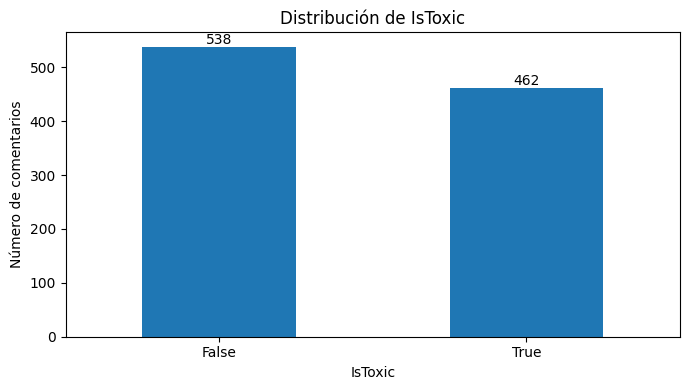

In [22]:
import matplotlib.pyplot as plt

toxic_counts = df["IsToxic"].value_counts().reindex([False, True])

ax = toxic_counts.plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_title("Distribución de IsToxic")
ax.set_xlabel("IsToxic")
ax.set_ylabel("Número de comentarios")
ax.set_xticklabels(["False", "True"], rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 4.3 Balance de la etiqueta

Analizamos la proporción entre las clases de `IsToxic` para determinar si existe un desbalance relevante en la muestra disponible.

Esta distribución será importante posteriormente al seleccionar e interpretar las métricas de evaluación del sistema de triaje.

In [23]:
toxic_true = df["IsToxic"].sum()
toxic_false = (~df["IsToxic"]).sum()

toxic_percentage = toxic_true / len(df) * 100
non_toxic_percentage = toxic_false / len(df) * 100
class_ratio = toxic_false / toxic_true

print(f"IsToxic = True: {toxic_true} ({toxic_percentage:.1f}%)")
print(f"IsToxic = False: {toxic_false} ({non_toxic_percentage:.1f}%)")
print(f"Relación False/True: {class_ratio:.2f}")

IsToxic = True: 462 (46.2%)
IsToxic = False: 538 (53.8%)
Relación False/True: 1.16


### Conclusiones

**Hechos observados**

De los 1.000 comentarios del dataset, 462 (46,2 %) presentan `IsToxic = True` y 538 (53,8 %) presentan `IsToxic = False`. La relación entre ambas clases es de aproximadamente 1,16 comentarios etiquetados como no tóxicos por cada comentario etiquetado como tóxico.

**Interpretación**

`IsToxic` no presenta un desbalance fuerte en la muestra disponible, ya que ambas clases cuentan con una representación similar. Esto permite disponer de un número relevante de ejemplos de ambas clases para los análisis posteriores.

Para el MVP, `IsToxic` constituye la referencia observada con la que posteriormente podrá evaluarse una estimación de toxicidad utilizada como señal dentro del sistema de triaje. Sin embargo, la etiqueta no representa por sí misma una puntuación de riesgo, una medida de incertidumbre ni una decisión de moderación.

La distribución observada tampoco permite concluir que el 46,2 % de los comentarios de YouTube sean tóxicos, ya que este porcentaje describe únicamente la muestra disponible y no se ha demostrado que sea representativa de una población más amplia.

**Implicaciones para el proyecto**

El balance de `IsToxic` no plantea, por sí solo, un problema evidente de representación entre las dos clases principales. No obstante, la futura evaluación no deberá basarse únicamente en esta distribución ni en métricas globales de clasificación.

Dado que el objetivo del MVP es priorizar comentarios para revisión humana, posteriormente será necesario evaluar tanto la capacidad de identificar comentarios etiquetados como tóxicos como la calidad de su ordenación en una cola de revisión, utilizando las métricas definidas para el proyecto cuando existan predicciones del modelo.

Antes de ello, es necesario comprender cómo se relaciona `IsToxic` con las etiquetas secundarias y qué información adicional aporta la estructura de etiquetado.

## 5. Análisis de etiquetas secundarias y relación con `IsToxic`

### 5.1 Distribución y cobertura de las etiquetas secundarias

Además de `IsToxic`, el dataset contiene once etiquetas secundarias asociadas a distintas categorías de contenido.

Analizamos su frecuencia y porcentaje de casos positivos para conocer qué categorías están representadas en la muestra y detectar diferencias importantes de cobertura.

Este análisis describe únicamente las etiquetas disponibles. No permite inferir la frecuencia real de estas categorías fuera del dataset ni reconstruir por sí solo el proceso original de anotación.

In [24]:
secondary_labels = [
    column for column in label_columns
    if column != "IsToxic"
]

secondary_distribution = pd.DataFrame({
    "positivos": df[secondary_labels].sum(),
    "negativos": (~df[secondary_labels]).sum()
})

secondary_distribution["porcentaje_positivo"] = (
    secondary_distribution["positivos"] / len(df) * 100
).round(2)

secondary_distribution = secondary_distribution.sort_values(
    "porcentaje_positivo",
    ascending=False
)

secondary_distribution

,positivos,negativos,porcentaje_positivo
IsAbusive,353,647,35.3
IsProvocative,161,839,16.1
IsHatespeech,138,862,13.8
IsRacist,125,875,12.5
IsObscene,100,900,10.0
IsThreat,21,979,2.1
IsReligiousHate,12,988,1.2
IsNationalist,8,992,0.8
IsSexist,1,999,0.1
IsHomophobic,0,1000,0.0


### 5.2 Visualización de la cobertura

Representamos el porcentaje de casos positivos de cada etiqueta secundaria para comparar su presencia en el dataset.

La visualización permite identificar diferencias de cobertura entre categorías y detectar etiquetas con una representación especialmente reducida o sin casos positivos en la muestra.

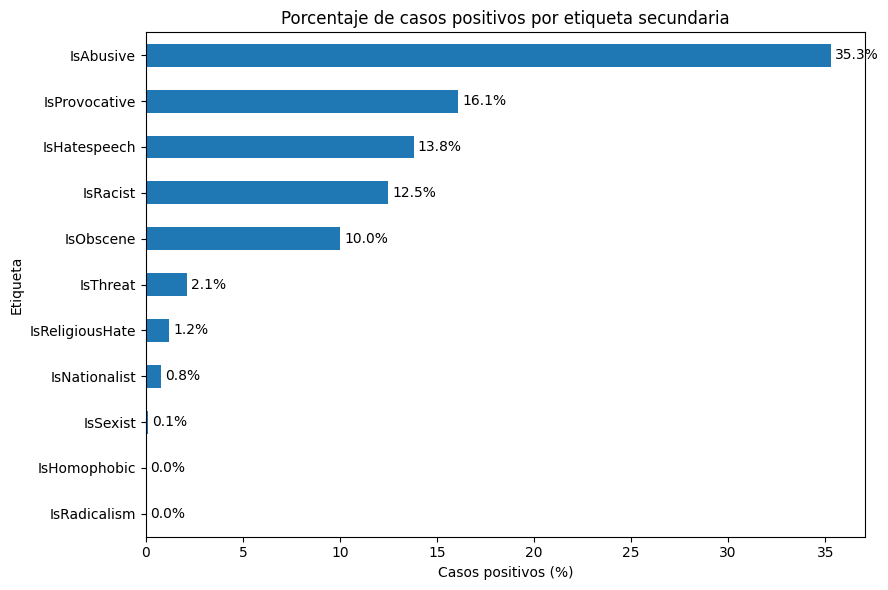

In [25]:
ax = secondary_distribution["porcentaje_positivo"].plot(
    kind="barh",
    figsize=(9, 6)
)

ax.set_title("Porcentaje de casos positivos por etiqueta secundaria")
ax.set_xlabel("Casos positivos (%)")
ax.set_ylabel("Etiqueta")

ax.invert_yaxis()

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

### 5.3 Cobertura de las categorías

La cobertura de las etiquetas secundarias es muy desigual. `IsAbusive` es la categoría con mayor presencia, con 353 casos positivos (35,3 %), seguida por `IsProvocative` (16,1 %), `IsHatespeech` (13,8 %), `IsRacist` (12,5 %) e `IsObscene` (10,0 %).

Otras categorías tienen una representación considerablemente menor: `IsThreat` cuenta con 21 casos positivos (2,1 %), `IsReligiousHate` con 12 (1,2 %), `IsNationalist` con 8 (0,8 %) e `IsSexist` con un único caso positivo (0,1 %).

`IsHomophobic` e `IsRadicalism` no presentan ningún caso positivo en los 1.000 registros analizados.

Esta distribución limita la evidencia disponible para estudiar de forma independiente las categorías con muy pocos casos positivos y, especialmente, aquellas sin ejemplos positivos. Este aspecto deberá considerarse posteriormente al definir qué categorías pueden evaluarse de forma fiable con esta muestra.

Estos resultados describen únicamente la cobertura observada en el dataset y no permiten inferir la prevalencia real de estas categorías en comentarios de YouTube.

In [26]:
coverage_summary = secondary_distribution[
    ["positivos", "porcentaje_positivo"]
].copy()

labels_without_positives = coverage_summary[
    coverage_summary["positivos"] == 0
].index.tolist()

labels_with_few_positives = coverage_summary[
    coverage_summary["positivos"].between(1, 20)
].index.tolist()

print("Cobertura de las etiquetas secundarias:")
display(coverage_summary)

print(f"\nEtiquetas sin casos positivos: {labels_without_positives}")
print(
    "Etiquetas con entre 1 y 20 casos positivos: "
    f"{labels_with_few_positives}"
)

Cobertura de las etiquetas secundarias:


,positivos,porcentaje_positivo
IsAbusive,353,35.3
IsProvocative,161,16.1
IsHatespeech,138,13.8
IsRacist,125,12.5
IsObscene,100,10.0
IsThreat,21,2.1
IsReligiousHate,12,1.2
IsNationalist,8,0.8
IsSexist,1,0.1
IsHomophobic,0,0.0



Etiquetas sin casos positivos: ['IsHomophobic', 'IsRadicalism']
Etiquetas con entre 1 y 20 casos positivos: ['IsReligiousHate', 'IsNationalist', 'IsSexist']


#### Conclusión

La cobertura de las etiquetas secundarias es muy desigual. `IsAbusive` concentra el mayor número de casos positivos (353; 35,3 %), mientras que varias categorías presentan una representación muy reducida.

`IsReligiousHate`, `IsNationalist` e `IsSexist` cuentan únicamente con 12, 8 y 1 casos positivos, respectivamente. Además, `IsHomophobic` e `IsRadicalism` no presentan ningún caso positivo en los 1.000 registros analizados.

Estos resultados limitan la evidencia disponible para analizar y evaluar de forma independiente las categorías menos representadas. En particular, las categorías sin casos positivos no pueden evaluarse respecto a la detección de su clase positiva utilizando únicamente esta muestra.

Esta cobertura describe exclusivamente el dataset disponible y no implica que dichas categorías sean inexistentes o infrecuentes fuera de la muestra.

### 5.4 Relación entre `IsToxic` y las etiquetas secundarias

Analizamos si `IsToxic` coincide, registro a registro, con la presencia de al menos una etiqueta secundaria positiva.

El objetivo es comprobar empíricamente la relación entre la etiqueta general de toxicidad y las once categorías secundarias. Esta comprobación permite conocer mejor la estructura del etiquetado disponible y determinar si las etiquetas secundarias aportan información independiente respecto a `IsToxic`.

Una posible coincidencia completa describe una relación observada en este dataset, pero no demuestra cómo fue construido originalmente el sistema de anotación.

In [27]:
has_secondary_positive = df[secondary_labels].any(axis=1)

matches_toxic = df["IsToxic"].eq(has_secondary_positive)

n_matches = matches_toxic.sum()
n_mismatches = (~matches_toxic).sum()

toxic_without_secondary = (
    df["IsToxic"] & ~has_secondary_positive
).sum()

secondary_without_toxic = (
    ~df["IsToxic"] & has_secondary_positive
).sum()

print(f"Coincidencias: {n_matches} de {len(df)}")
print(f"Discrepancias: {n_mismatches}")
print(
    "IsToxic=True sin etiquetas secundarias positivas: "
    f"{toxic_without_secondary}"
)
print(
    "IsToxic=False con alguna etiqueta secundaria positiva: "
    f"{secondary_without_toxic}"
)

Coincidencias: 1000 de 1000
Discrepancias: 0
IsToxic=True sin etiquetas secundarias positivas: 0
IsToxic=False con alguna etiqueta secundaria positiva: 0


In [28]:
relationship_table = pd.crosstab(
    df["IsToxic"],
    has_secondary_positive,
    rownames=["IsToxic"],
    colnames=["Alguna etiqueta secundaria positiva"]
)

relationship_table

Alguna etiqueta secundaria positiva,False,True
IsToxic,,
False,538,0
True,0,462


#### Conclusión

En los 1.000 registros analizados existe una correspondencia exacta entre `IsToxic` y la presencia de al menos una etiqueta secundaria positiva.

Los 462 comentarios con `IsToxic = True` presentan una o más etiquetas secundarias positivas, mientras que los 538 comentarios con `IsToxic = False` no presentan ninguna. No se observa ninguna discrepancia entre ambas condiciones.

Por tanto, en este dataset se cumple empíricamente:

`IsToxic = True` ↔ al menos una etiqueta secundaria = `True`

Este resultado demuestra una equivalencia entre las variables dentro de la muestra analizada, pero no permite determinar cómo se generaron originalmente las anotaciones. En particular, sin documentación sobre el proceso de etiquetado no puede afirmarse que `IsToxic` haya sido calculada mediante una operación lógica OR sobre las etiquetas secundarias.

Para el proyecto, esta relación también implica que las etiquetas secundarias no deben utilizarse posteriormente como variables predictoras de `IsToxic`, ya que incorporarían directamente información asociada a la etiqueta objetivo y producirían fuga de información.

### 5.5 Número de etiquetas secundarias positivas por comentario

La equivalencia observada con `IsToxic` indica si existe al menos una categoría secundaria positiva, pero no muestra cuántas categorías pueden coexistir en un mismo comentario.

Calculamos el número de etiquetas secundarias positivas por registro para estudiar el carácter multietiqueta del dataset y conocer el grado de solapamiento entre categorías.

In [29]:
secondary_positive_count = df[secondary_labels].sum(axis=1)

positive_count_distribution = (
    secondary_positive_count
    .value_counts()
    .sort_index()
    .rename_axis("numero_etiquetas_positivas")
    .to_frame("comentarios")
)

positive_count_distribution["porcentaje"] = (
    positive_count_distribution["comentarios"] / len(df) * 100
).round(2)

positive_count_distribution

,comentarios,porcentaje
numero_etiquetas_positivas,,
0,538,53.8
1,100,10.0
2,294,29.4
3,47,4.7
4,15,1.5
5,6,0.6


In [30]:
toxic_secondary_count = secondary_positive_count[df["IsToxic"]]

print(
    "Comentarios IsToxic=True: "
    f"{len(toxic_secondary_count)}"
)
print(
    "Mínimo de etiquetas secundarias positivas: "
    f"{toxic_secondary_count.min()}"
)
print(
    "Máximo de etiquetas secundarias positivas: "
    f"{toxic_secondary_count.max()}"
)
print(
    "Media de etiquetas secundarias positivas: "
    f"{toxic_secondary_count.mean():.2f}"
)

Comentarios IsToxic=True: 462
Mínimo de etiquetas secundarias positivas: 1
Máximo de etiquetas secundarias positivas: 5
Media de etiquetas secundarias positivas: 1.99


#### Conclusión

El dataset presenta una estructura multietiqueta entre las categorías secundarias. De los 1.000 comentarios, 538 no presentan ninguna etiqueta secundaria positiva, mientras que los 462 restantes presentan entre una y cinco.

Entre los comentarios con `IsToxic = True`, 100 presentan una única etiqueta secundaria positiva y 362 presentan dos o más. Por tanto, aproximadamente el 78,4 % de los comentarios etiquetados como tóxicos pertenece simultáneamente a más de una categoría secundaria.

El número más frecuente entre los comentarios con etiquetas positivas es de dos categorías, con 294 registros. En el conjunto de comentarios `IsToxic = True`, la media es de 1,99 etiquetas secundarias positivas por comentario.

Estos resultados muestran un solapamiento considerable entre las categorías secundarias. Las etiquetas no deben interpretarse como clases mutuamente excluyentes: un mismo comentario puede estar asociado simultáneamente a distintos tipos de contenido.

Este solapamiento hace necesario estudiar qué etiquetas tienden a aparecer conjuntamente antes de interpretar cada categoría de forma independiente.

### 5.6 Coocurrencia entre etiquetas secundarias

Dado que la mayoría de los comentarios `IsToxic = True` presenta más de una etiqueta secundaria positiva, analizamos la coocurrencia entre categorías.

La matriz de coocurrencia muestra cuántos comentarios presentan simultáneamente cada par de etiquetas. Este análisis permite identificar relaciones frecuentes entre categorías sin asumir que exista causalidad, dependencia semántica o una jerarquía definida por el proceso de anotación.

In [31]:
cooccurrence_matrix = (
    df[secondary_labels]
    .astype(int)
    .T
    .dot(df[secondary_labels].astype(int))
)

cooccurrence_matrix

,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
IsAbusive,353,21,161,100,29,25,1,1,0,2,0
IsThreat,21,21,9,0,3,1,0,0,0,2,0
IsProvocative,161,9,161,26,13,11,1,0,0,2,0
IsObscene,100,0,26,100,11,9,0,1,0,0,0
IsHatespeech,29,3,13,11,138,125,8,1,0,12,0
IsRacist,25,1,11,9,125,125,8,0,0,2,0
IsNationalist,1,0,1,0,8,8,8,0,0,0,0
IsSexist,1,0,0,1,1,0,0,1,0,0,0
IsHomophobic,0,0,0,0,0,0,0,0,0,0,0
IsReligiousHate,2,2,2,0,12,2,0,0,0,12,0


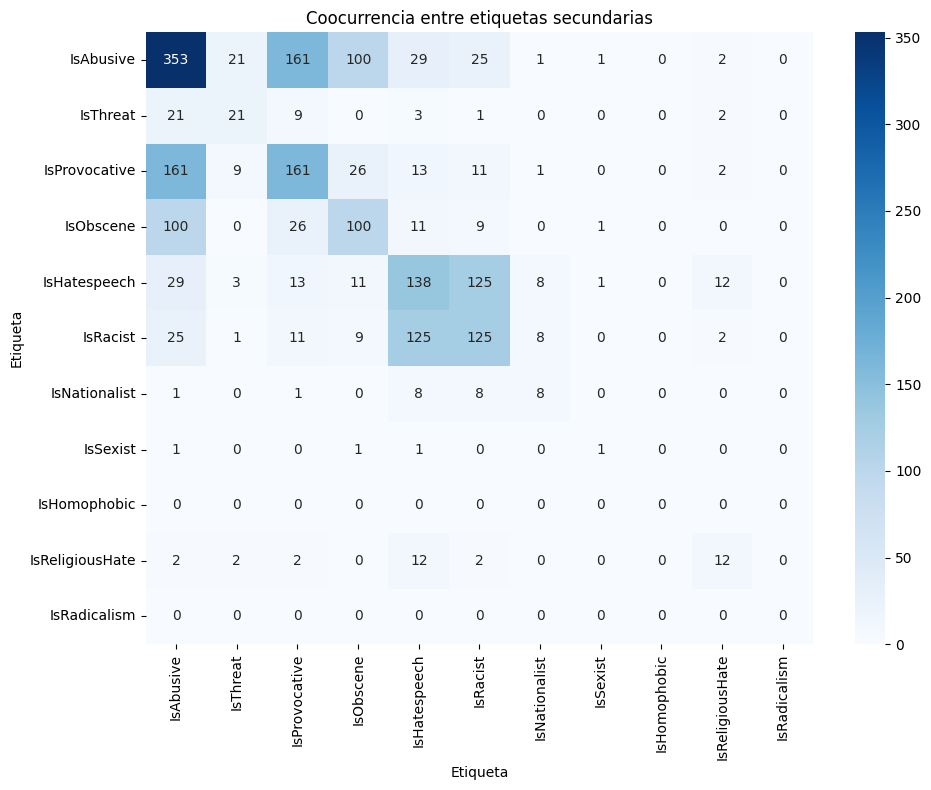

In [32]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    cooccurrence_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Coocurrencia entre etiquetas secundarias")
plt.xlabel("Etiqueta")
plt.ylabel("Etiqueta")
plt.tight_layout()
plt.show()

#### Pares con mayor coocurrencia

Para complementar la matriz, extraemos las combinaciones de dos etiquetas que aparecen conjuntamente con mayor frecuencia. Se excluye la diagonal de la matriz para evitar contar la frecuencia individual de cada categoría.

In [33]:
cooccurrence_pairs = []

for i, label_1 in enumerate(secondary_labels):
    for j in range(i + 1, len(secondary_labels)):
        label_2 = secondary_labels[j]
        count = cooccurrence_matrix.loc[label_1, label_2]

        if count > 0:
            cooccurrence_pairs.append({
                "etiqueta_1": label_1,
                "etiqueta_2": label_2,
                "coocurrencias": int(count)
            })

cooccurrence_pairs = (
    pd.DataFrame(cooccurrence_pairs)
    .sort_values("coocurrencias", ascending=False)
    .reset_index(drop=True)
)

cooccurrence_pairs.head(10)

,etiqueta_1,etiqueta_2,coocurrencias
0,IsAbusive,IsProvocative,161
1,IsHatespeech,IsRacist,125
2,IsAbusive,IsObscene,100
3,IsAbusive,IsHatespeech,29
4,IsProvocative,IsObscene,26
5,IsAbusive,IsRacist,25
6,IsAbusive,IsThreat,21
7,IsProvocative,IsHatespeech,13
8,IsHatespeech,IsReligiousHate,12
9,IsObscene,IsHatespeech,11


In [34]:
containment_checks = pd.DataFrame({
    "relacion": [
        "IsProvocative -> IsAbusive",
        "IsRacist -> IsHatespeech",
        "IsNationalist -> IsHatespeech",
        "IsReligiousHate -> IsHatespeech"
    ],
    "casos_origen": [
        df["IsProvocative"].sum(),
        df["IsRacist"].sum(),
        df["IsNationalist"].sum(),
        df["IsReligiousHate"].sum()
    ],
    "casos_origen_sin_destino": [
        (df["IsProvocative"] & ~df["IsAbusive"]).sum(),
        (df["IsRacist"] & ~df["IsHatespeech"]).sum(),
        (df["IsNationalist"] & ~df["IsHatespeech"]).sum(),
        (df["IsReligiousHate"] & ~df["IsHatespeech"]).sum()
    ]
})

containment_checks

,relacion,casos_origen,casos_origen_sin_destino
0,IsProvocative -> IsAbusive,161,0
1,IsRacist -> IsHatespeech,125,0
2,IsNationalist -> IsHatespeech,8,0
3,IsReligiousHate -> IsHatespeech,12,0


#### Conclusión

El análisis de coocurrencia confirma que las etiquetas secundarias presentan un solapamiento importante y que algunas relaciones de inclusión se cumplen sin excepciones en los 1.000 registros analizados.

En particular:

- Los 161 casos etiquetados como `IsProvocative` también están etiquetados como `IsAbusive`.
- Los 125 casos etiquetados como `IsRacist` también están etiquetados como `IsHatespeech`.
- Los 8 casos etiquetados como `IsNationalist` también están etiquetados como `IsHatespeech`.
- Los 12 casos etiquetados como `IsReligiousHate` también están etiquetados como `IsHatespeech`.

Estas relaciones muestran que las categorías no funcionan como clases independientes ni mutuamente excluyentes dentro de la muestra. Algunas etiquetas aparecen sistemáticamente asociadas a categorías más amplias, lo que puede afectar a la interpretación de sus frecuencias y a una futura evaluación por categoría.

Sin documentación sobre el proceso de anotación, estos patrones no permiten afirmar que exista una jerarquía formal entre las etiquetas ni que unas hayan sido derivadas de otras. Las relaciones descritas corresponden únicamente a la estructura observada en este dataset.

Para el sistema de triaje, las etiquetas secundarias pueden aportar información descriptiva sobre los tipos de contenido presentes, pero no deben interpretarse automáticamente como dimensiones independientes de riesgo.

### 5.7 Combinaciones de etiquetas secundarias

Analizamos las combinaciones exactas de etiquetas secundarias presentes en cada comentario para identificar los perfiles de anotación más frecuentes.

Este análisis complementa la matriz de coocurrencia, ya que permite observar conjuntamente todas las etiquetas positivas de un registro en lugar de estudiar únicamente relaciones por pares.

In [35]:
def get_positive_labels(row):
    return tuple(
        label
        for label in secondary_labels
        if row[label]
    )

label_combinations = df[secondary_labels].apply(
    get_positive_labels,
    axis=1
)

combination_distribution = (
    label_combinations
    .value_counts()
    .rename_axis("combinacion")
    .to_frame("comentarios")
)

combination_distribution["porcentaje"] = (
    combination_distribution["comentarios"] / len(df) * 100
).round(2)

combination_distribution.head(15)

,comentarios,porcentaje
combinacion,,
(),538,53.8
"(IsAbusive, IsProvocative)",118,11.8
"(IsAbusive,)",99,9.9
"(IsHatespeech, IsRacist)",91,9.1
"(IsAbusive, IsObscene)",66,6.6
"(IsAbusive, IsProvocative, IsObscene)",23,2.3
"(IsAbusive, IsThreat)",11,1.1
"(IsHatespeech, IsReligiousHate)",8,0.8
"(IsAbusive, IsHatespeech, IsRacist)",7,0.7


#### Conclusión

Las combinaciones de etiquetas confirman la naturaleza multietiqueta del dataset. Los 538 comentarios sin etiquetas secundarias positivas representan el 53,8 % de la muestra y coinciden con los registros `IsToxic = False`.

Entre los comentarios con etiquetas secundarias positivas no existe una única combinación dominante. Las configuraciones más frecuentes son `IsAbusive + IsProvocative` (118 comentarios; 11,8 % del total), `IsAbusive` como única etiqueta secundaria (99; 9,9 %), `IsHatespeech + IsRacist` (91; 9,1 %) e `IsAbusive + IsObscene` (66; 6,6 %).

También aparecen combinaciones de tres o más categorías, lo que refuerza la evidencia de que las etiquetas secundarias no son mutuamente excluyentes.

Los patrones observados son coherentes con las relaciones de inclusión detectadas anteriormente, pero no permiten reconstruir el proceso original de anotación ni afirmar que exista una jerarquía formal entre categorías.

Para el objetivo del proyecto, `IsToxic` puede utilizarse posteriormente como referencia para estudiar toxicidad estimada, mientras que las etiquetas secundarias aportan contexto descriptivo sobre la anotación. El dataset no contiene una etiqueta específica de contenido violento, por lo que este EDA no permite medir directamente ese fenómeno; su ausencia como variable no implica que dicho contenido no pueda existir en los comentarios.

## 6. Análisis descriptivo del texto

El texto de los comentarios constituye la principal información disponible para una futura estimación de `IsToxic`. En esta sección analizamos características descriptivas del contenido textual sin modificarlo ni aplicar técnicas de preprocesamiento o modelado.

El objetivo es conocer la variabilidad de los comentarios y detectar características que puedan ser relevantes tanto para la revisión humana como para las decisiones posteriores de preparación de los datos.

### 6.1 Longitud en caracteres y palabras

Analizamos la longitud de los comentarios en caracteres y palabras para conocer la variabilidad del contenido textual y detectar posibles valores extremos.

Las medidas se calculan sobre el texto original, sin normalización ni limpieza, por lo que describen el dataset tal como se encuentra en la fuente.

In [36]:
text_analysis = pd.DataFrame({
    "longitud_caracteres": df["Text"].str.len(),
    "numero_palabras": df["Text"].str.split().str.len()
})

text_analysis.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

,longitud_caracteres,numero_palabras
count,1000.00,1000.00
mean,185.55,33.78
std,270.78,49.07
min,3.00,1.00
25%,47.00,9.00
50%,101.00,19.00
75%,217.00,39.00
90%,430.30,79.00
95%,633.35,114.15
99%,1220.42,209.15


In [37]:
text_length_summary = pd.DataFrame({
    "caracteres": [
        text_analysis["longitud_caracteres"].min(),
        text_analysis["longitud_caracteres"].median(),
        text_analysis["longitud_caracteres"].mean(),
        text_analysis["longitud_caracteres"].max()
    ],
    "palabras": [
        text_analysis["numero_palabras"].min(),
        text_analysis["numero_palabras"].median(),
        text_analysis["numero_palabras"].mean(),
        text_analysis["numero_palabras"].max()
    ]
}, index=["mínimo", "mediana", "media", "máximo"]).round(2)

text_length_summary

,caracteres,palabras
mínimo,3.00,1.00
mediana,101.00,19.00
media,185.55,33.78
máximo,4421.00,815.00


#### Conclusión

La longitud de los comentarios presenta una variabilidad considerable. La mediana es de 101 caracteres y 19 palabras, mientras que la media asciende a 185,55 caracteres y 33,78 palabras.

La diferencia entre media y mediana, junto con los percentiles superiores, indica una distribución asimétrica hacia comentarios largos. El 99 % de los registros contiene aproximadamente hasta 1.220 caracteres y 209 palabras, mientras que el máximo observado alcanza 4.421 caracteres y 815 palabras.

También existen comentarios muy breves, con mínimos de 3 caracteres y 1 palabra.

Estos resultados muestran que el sistema de triaje deberá trabajar con textos de longitudes muy diferentes. Los valores extremos deben analizarse antes de decidir cualquier tratamiento posterior, pero durante el EDA no se eliminan ni se modifican.

### 6.2 Distribución de la longitud de los comentarios

Visualizamos la distribución del número de palabras para observar la concentración de los comentarios y el efecto de los textos especialmente largos.

Dado que existen valores extremos, se representa también el percentil 99 como referencia descriptiva, sin eliminar observaciones del dataset.

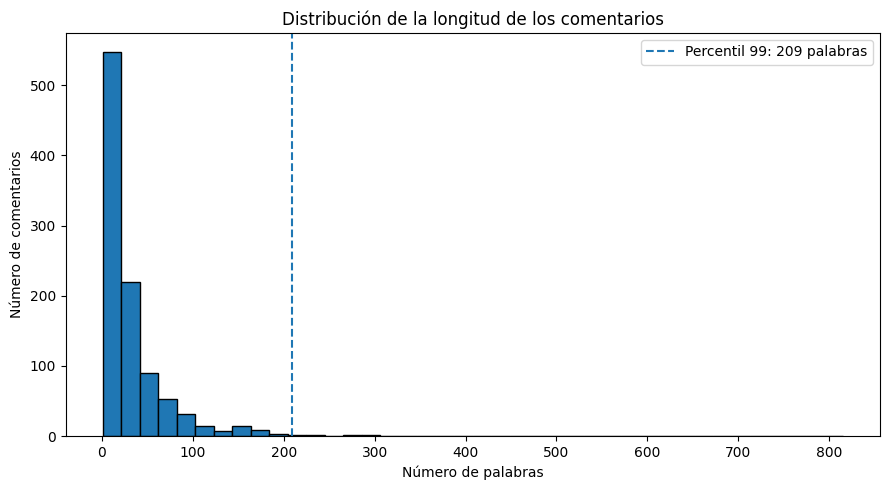

In [38]:
p99_words = text_analysis["numero_palabras"].quantile(0.99)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    text_analysis["numero_palabras"],
    bins=40,
    edgecolor="black"
)

ax.axvline(
    p99_words,
    linestyle="--",
    label=f"Percentil 99: {p99_words:.0f} palabras"
)

ax.set_title("Distribución de la longitud de los comentarios")
ax.set_xlabel("Número de palabras")
ax.set_ylabel("Número de comentarios")
ax.legend()

plt.tight_layout()
plt.show()

#### Conclusión

La distribución de la longitud de los comentarios presenta una clara asimetría hacia la derecha. La mayor parte de los textos se concentra en longitudes relativamente reducidas, mientras que un número pequeño de comentarios alcanza longitudes considerablemente mayores.

El percentil 99 se sitúa aproximadamente en 209 palabras, lo que indica que el 99 % de los comentarios tiene una longitud igual o inferior a este valor. Sin embargo, el máximo observado alcanza 815 palabras, confirmando la existencia de una cola larga y de algunos comentarios excepcionalmente extensos.

Estos valores extremos se mantienen durante el EDA. Su posible tratamiento deberá decidirse posteriormente durante el diseño del preprocesamiento, teniendo en cuenta las necesidades del sistema de triaje.

### 6.3 Análisis de comentarios extremos

La distribución de longitud muestra una cola pronunciada y algunos comentarios considerablemente más extensos que el resto. En esta sección se examinan los textos situados en los extremos de la distribución para comprobar si corresponden a observaciones válidas o presentan características que deban considerarse posteriormente durante el preprocesamiento.

El objetivo es describir estos casos sin modificarlos ni eliminarlos durante el EDA.

In [39]:
p01_words = text_analysis["numero_palabras"].quantile(0.01)
p99_words = text_analysis["numero_palabras"].quantile(0.99)

short_comments = text_analysis[
    text_analysis["numero_palabras"] <= p01_words
].sort_values("numero_palabras")

long_comments = text_analysis[
    text_analysis["numero_palabras"] >= p99_words
].sort_values("numero_palabras", ascending=False)

print(f"Percentil 1: {p01_words:.0f} palabras")
print(f"Percentil 99: {p99_words:.0f} palabras")
print(f"Comentarios en el extremo inferior: {len(short_comments)}")
print(f"Comentarios en el extremo superior: {len(long_comments)}")

Percentil 1: 1 palabras
Percentil 99: 209 palabras
Comentarios en el extremo inferior: 12
Comentarios en el extremo superior: 10


In [41]:
extreme_short_view = df.loc[
    short_comments.index,
    ["CommentId", "VideoId", "Text", "IsToxic"]
].copy()

extreme_short_view["numero_palabras"] = short_comments["numero_palabras"]
extreme_short_view["longitud_caracteres"] = short_comments["longitud_caracteres"]

extreme_long_view = df.loc[
    long_comments.index,
    ["CommentId", "VideoId", "Text", "IsToxic"]
].copy()

extreme_long_view["numero_palabras"] = long_comments["numero_palabras"]
extreme_long_view["longitud_caracteres"] = long_comments["longitud_caracteres"]

# Fragmento del texto para facilitar la inspección.
extreme_short_view["texto_muestra"] = extreme_short_view["Text"].str.slice(0, 150)
extreme_long_view["texto_muestra"] = extreme_long_view["Text"].str.slice(0, 150)

print("Comentarios del extremo inferior:")
display(
    extreme_short_view[
        ["CommentId", "VideoId", "numero_palabras",
         "longitud_caracteres", "IsToxic", "texto_muestra"]
    ]
)

print("\nComentarios del extremo superior:")
display(
    extreme_long_view[
        ["CommentId", "VideoId", "numero_palabras",
         "longitud_caracteres", "IsToxic", "texto_muestra"]
    ]
)

Comentarios del extremo inferior:


,CommentId,VideoId,numero_palabras,longitud_caracteres,IsToxic,texto_muestra
105,Ugip7WiT0N70OngCoAEC,04kJtp6pVXI,1,6,False,Wow!!!
433,Ugiq0SQkpRsy9HgCoAEC,9pr1oE34bIM,1,3,False,wtf
595,Ugj-0RTLVplXZngCoAEC,cT14IbTDW2c,1,15,False,#alllivesmatter
627,UgwU6iBhWreyw_Dlwet4AaABAg,cT14IbTDW2c,1,6,True,Idiots
691,Ugz6twWBrqe70jW9z6J4AaABAg,cT14IbTDW2c,1,6,True,Idiotz
717,Ugi-AutQK-PGmHgCoAEC,dDbRyFIkNII,1,14,False,Wow...........
745,UggsmHAjXe_lhXgCoAEC,dG7mZQvaQDk,1,8,False,Respect!
788,UgiFAwQp3PHa83gCoAEC,dG7mZQvaQDk,1,6,False,Bravo!
837,Ugg2ItA50j3R8HgCoAEC,Dt9-byUhPdg,1,21,True,#blacklivesdontmatter
845,Ugi6WB0_Hv-gLngCoAEC,Dt9-byUhPdg,1,5,False,GOOD



Comentarios del extremo superior:


,CommentId,VideoId,numero_palabras,longitud_caracteres,IsToxic,texto_muestra
174,UggOHjEF4Yr5p3gCoAEC,4rCweDxDqdw,815,4421,True,"THE UGLY TRUTH:\n\nIf you talk like a THUG, ac..."
126,UgjBBBmH3xFa6ngCoAEC,04kJtp6pVXI,418,2292,False,*WHAT DOES TRAYVON MARTIN AND MICHAEL BROWN HA...
815,Ugjd5gn07ocXsngCoAEC,dG7mZQvaQDk,347,2104,False,"Thank you. Finally, a powerful voice for the t..."
190,Ugi4kKODyEmlvXgCoAEC,4rCweDxDqdw,295,1646,True,Someone has to say this so I will.\nWith the w...
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,287,1558,False,If only people would just take a step back and...
553,UgiSptL-dfSRVXgCoAEC,bUgKZMSxr3E,282,1646,False,Here in Finland with a population of over 5 mi...
415,UgiIiGH-eTP3AXgCoAEC,9pr1oE34bIM,274,1428,True,"As a white guy, if you are really concerned wi..."
365,UghpgVkCd2y1k3gCoAEC,9pr1oE34bIM,242,1355,True,"Seriously, YouTube? Go FUCK yourself. I find..."
287,UggJv-n9AXs0rXgCoAEC,9pr1oE34bIM,234,1377,False,Here is an intellectual and mature approach to...
565,UgyLxA__utHo58p6bhF4AaABAg,bUgKZMSxr3E,224,1129,False,It’s not that easy to be a cop. “I have a lot ...


#### Conclusión

El análisis de los extremos de longitud muestra que los comentarios muy cortos y muy largos no pueden considerarse automáticamente anomalías.

En el extremo inferior se identificaron 12 comentarios de una sola palabra. La inspección muestra que contienen expresiones breves pero potencialmente informativas, y se observan tanto registros `IsToxic = True` como `IsToxic = False`. Por tanto, una longitud mínima no constituye por sí sola un criterio suficiente para eliminar observaciones.

En el extremo superior se identificaron 10 comentarios a partir del percentil 99, situado en 209 palabras. Estos registros alcanzan hasta 815 palabras y presentan contenido textual estructurado. También incluyen ejemplos de ambas clases de `IsToxic`, por lo que su longitud elevada tampoco permite clasificarlos directamente como ruido o datos inválidos.

En consecuencia, durante el EDA se conservan todos estos registros. La posible necesidad de truncamiento, límites de longitud u otras transformaciones deberá evaluarse posteriormente en función de la estrategia de preprocesamiento y de los requisitos del modelo.

### 6.4 Análisis descriptivo del contenido textual

Además de la longitud de los comentarios, resulta útil explorar qué términos aparecen con mayor frecuencia en el corpus.

El objetivo de este análisis es obtener una visión general del vocabulario presente en los comentarios y detectar patrones léxicos básicos. Para ello se construye una representación temporal en minúsculas y se extraen únicamente tokens alfabéticos.

Esta transformación se utiliza exclusivamente con fines descriptivos dentro del EDA y no modifica la columna `Text` original ni constituye una decisión de preprocesamiento para el futuro modelo.

In [42]:
import re
from collections import Counter

# Tokenización simple exclusivamente para el análisis descriptivo
tokens = []

for text in df["Text"].astype(str):
    text_tokens = re.findall(r"[A-Za-z']+", text.lower())
    tokens.extend(text_tokens)

# Frecuencia de cada token
token_counts = Counter(tokens)

total_tokens = len(tokens)
vocab_size = len(token_counts)
singletons = sum(freq == 1 for freq in token_counts.values())

print(f"Número total de tokens: {total_tokens:,}")
print(f"Vocabulario observado: {vocab_size:,} términos únicos")
print(f"Tokens que aparecen una sola vez: {singletons:,}")

Número total de tokens: 33,667
Vocabulario observado: 4,605 términos únicos
Tokens que aparecen una sola vez: 2,517


In [45]:
stopwords_eda = {
    "the", "a", "an", "and", "or", "but", "if", "then", "than",
    "to", "of", "in", "on", "at", "for", "from", "with", "by",
    "is", "are", "was", "were", "be", "been", "being",
    "i", "you", "he", "she", "it", "we", "they",
    "me", "my", "your", "his", "her", "our", "their",
    "this", "that", "these", "those",
    "do", "does", "did", "have", "has", "had",
    "as", "so", "not", "no", "yes"
}

filtered_counts = Counter(
    token
    for token in tokens
    if token not in stopwords_eda and len(token) > 1
)

top_terms = pd.DataFrame(
    filtered_counts.most_common(20),
    columns=["termino", "frecuencia"]
)

top_terms

,termino,frecuencia
0,people,257
1,black,253
2,all,210
3,police,178
4,what,160
5,like,153
6,just,152
7,get,143
8,white,140
9,about,121


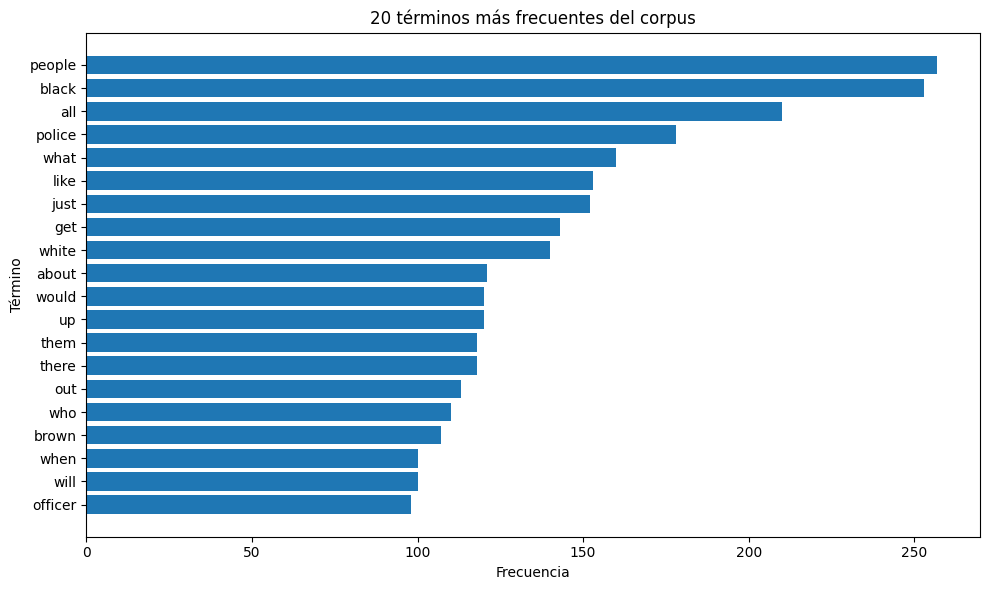

In [46]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_terms["termino"][::-1],
    top_terms["frecuencia"][::-1]
)

plt.title("20 términos más frecuentes del corpus")
plt.xlabel("Frecuencia")
plt.ylabel("Término")

plt.tight_layout()
plt.show()

#### Conclusión

El corpus contiene 33.667 tokens y un vocabulario observado de 4.605 términos únicos. De estos, 2.517 aparecen una sola vez, lo que representa aproximadamente el 54,7 % del vocabulario. Esto muestra una diversidad léxica elevada y una presencia importante de términos de baja frecuencia.

Tras aplicar únicamente para esta exploración una lista básica de stopwords, los términos más frecuentes incluyen palabras como `people`, `black`, `police`, `white`, `brown` y `officer`, junto con diversos términos funcionales que no fueron incluidos en la lista de exclusión.

La presencia destacada de términos relacionados con personas, grupos y policía permite caracterizar temáticamente parte del contenido de la muestra, pero su frecuencia aislada no permite determinar si están asociados con toxicidad ni interpretar su uso sin considerar el contexto del comentario.

Además, la permanencia de palabras funcionales entre los términos más frecuentes evidencia que la lista de stopwords utilizada es deliberadamente limitada. Este resultado no se interpreta como un problema del dataset, ya que la eliminación de stopwords y otras decisiones de normalización deberán evaluarse posteriormente como parte del preprocesamiento.

Por tanto, este apartado tiene únicamente carácter descriptivo: no se han eliminado términos del dataset ni se ha definido todavía una estrategia definitiva de tokenización o normalización.

### 6.5 Relación entre longitud del texto e `IsToxic`

Una vez caracterizada la longitud de los comentarios, se analiza si existen diferencias descriptivas entre los comentarios etiquetados como tóxicos y no tóxicos.

Se comparan el número de palabras y la longitud en caracteres para `IsToxic = True` e `IsToxic = False`.

El objetivo es identificar posibles diferencias en la distribución de la longitud, sin asumir que la longitud determine la toxicidad ni utilizarla todavía como característica de un modelo.

In [47]:
text_toxicity_analysis = pd.DataFrame({
    "IsToxic": df["IsToxic"],
    "numero_palabras": df["Text"].astype(str).str.split().str.len(),
    "longitud_caracteres": df["Text"].astype(str).str.len()
})

length_by_toxicity = (
    text_toxicity_analysis
    .groupby("IsToxic")
    .agg(
        comentarios=("IsToxic", "size"),
        media_palabras=("numero_palabras", "mean"),
        mediana_palabras=("numero_palabras", "median"),
        p75_palabras=("numero_palabras", lambda x: x.quantile(0.75)),
        p90_palabras=("numero_palabras", lambda x: x.quantile(0.90)),
        media_caracteres=("longitud_caracteres", "mean"),
        mediana_caracteres=("longitud_caracteres", "median")
    )
    .round(2)
)

length_by_toxicity

,comentarios,media_palabras,mediana_palabras,p75_palabras,p90_palabras,media_caracteres,mediana_caracteres
IsToxic,,,,,,,
False,538,33.07,18.0,38.0,80.6,182.26,96.0
True,462,34.60,20.0,40.0,76.8,189.39,110.0


<Figure size 800x500 with 0 Axes>

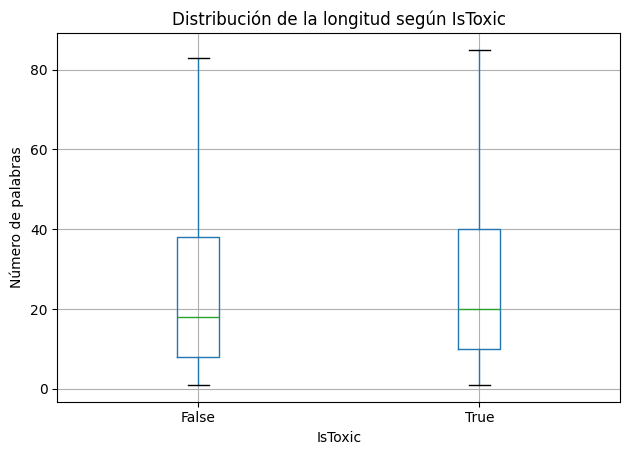

In [48]:
plt.figure(figsize=(8, 5))

text_toxicity_analysis.boxplot(
    column="numero_palabras",
    by="IsToxic",
    showfliers=False
)

plt.title("Distribución de la longitud según IsToxic")
plt.suptitle("")
plt.xlabel("IsToxic")
plt.ylabel("Número de palabras")
plt.tight_layout()
plt.show()

In [49]:
length_by_toxicity

,comentarios,media_palabras,mediana_palabras,p75_palabras,p90_palabras,media_caracteres,mediana_caracteres
IsToxic,,,,,,,
False,538,33.07,18.0,38.0,80.6,182.26,96.0
True,462,34.60,20.0,40.0,76.8,189.39,110.0


#### Conclusión

La comparación de la longitud de los comentarios según `IsToxic` muestra distribuciones similares entre ambas clases.

Los comentarios con `IsToxic = False` presentan una mediana de 18 palabras y 96 caracteres, mientras que los comentarios con `IsToxic = True` alcanzan medianas ligeramente superiores, de 20 palabras y 110 caracteres. Las medias también son próximas: 33,07 frente a 34,60 palabras y 182,26 frente a 189,39 caracteres, respectivamente.

El percentil 75 sigue un patrón similar, con 38 palabras para los comentarios no tóxicos y 40 para los tóxicos. Sin embargo, en el percentil 90 la relación se invierte: los comentarios no tóxicos alcanzan 80,6 palabras frente a 76,8 en los tóxicos.

El boxplot confirma un amplio solapamiento entre las distribuciones de ambas clases. Por tanto, aunque los comentarios etiquetados como tóxicos presentan valores centrales ligeramente superiores, no se observa una separación clara entre `IsToxic = True` e `IsToxic = False` basada únicamente en la longitud del texto.

Estos resultados son descriptivos y no permiten concluir que la longitud determine o prediga la toxicidad. La posible utilidad de características relacionadas con la longitud deberá evaluarse posteriormente durante el modelado.

## 7. Análisis por vídeo

Los comentarios del dataset proceden de un número reducido de vídeos. Esta estructura puede generar dependencia entre observaciones, ya que comentarios pertenecientes al mismo vídeo pueden compartir contexto, temática o vocabulario.

En esta sección se analiza la distribución de comentarios entre `VideoId` y la presencia de `IsToxic` dentro de cada vídeo. El objetivo es caracterizar esta estructura antes de definir posteriormente una estrategia de partición para el modelado.

### 7.1 Distribución de comentarios por `VideoId`

Se analiza cuántos comentarios aporta cada vídeo y qué proporción del dataset representa. Esto permite medir si la muestra está distribuida uniformemente o concentrada en unos pocos vídeos.

In [50]:
video_distribution = (
    df["VideoId"]
    .value_counts()
    .rename_axis("VideoId")
    .reset_index(name="comentarios")
)

video_distribution["porcentaje"] = (
    video_distribution["comentarios"] / len(df) * 100
).round(1)

video_distribution

,VideoId,comentarios,porcentaje
0,9pr1oE34bIM,274,27.4
1,04kJtp6pVXI,172,17.2
2,cT14IbTDW2c,146,14.6
3,dG7mZQvaQDk,112,11.2
4,TZxEyoplYbI,104,10.4
5,bUgKZMSxr3E,39,3.9
6,8HB18hZrhXc,38,3.8
7,4rCweDxDqdw,37,3.7
8,Dt9-byUhPdg,34,3.4
9,#NAME?,16,1.6


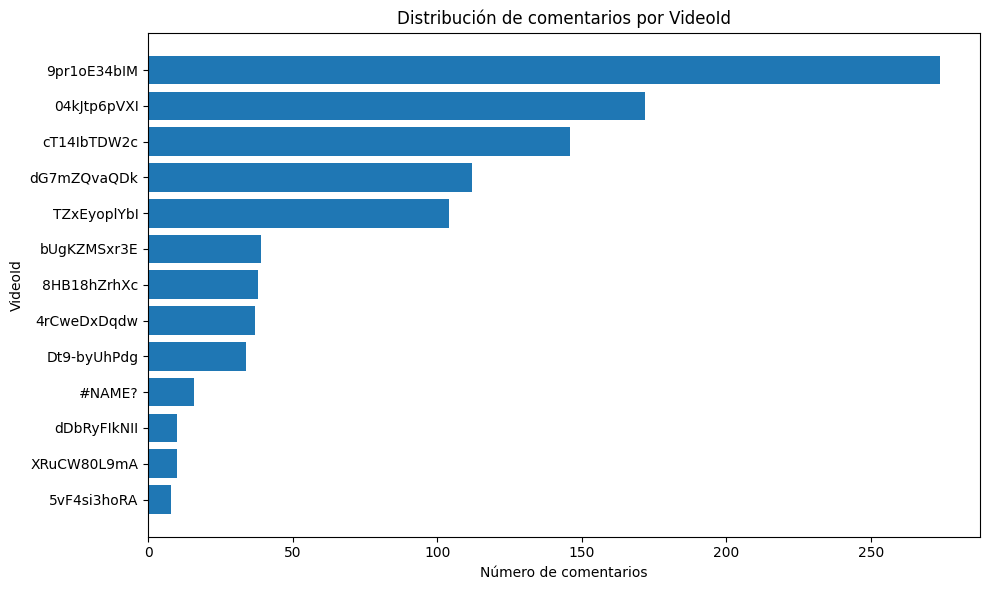

In [51]:
plt.figure(figsize=(10, 6))

plt.barh(
    video_distribution["VideoId"][::-1],
    video_distribution["comentarios"][::-1]
)

plt.title("Distribución de comentarios por VideoId")
plt.xlabel("Número de comentarios")
plt.ylabel("VideoId")

plt.tight_layout()
plt.show()

#### Conclusión

Los 1.000 comentarios del dataset se distribuyen entre únicamente 13 valores distintos de `VideoId`, y la representación entre ellos es claramente desigual.

El vídeo con mayor número de registros contiene 274 comentarios, equivalentes al 27,4 % del dataset. Los tres vídeos más representados acumulan 592 comentarios (59,2 %), mientras que los cinco primeros concentran 808 registros (80,8 %).

Por tanto, la muestra presenta una concentración elevada en un número reducido de vídeos. Esta estructura indica que los comentarios no deben considerarse necesariamente observaciones independientes respecto a su contexto de origen, ya que comentarios pertenecientes al mismo vídeo pueden compartir temática, audiencia o vocabulario.

También se mantiene el valor `VideoId = "#NAME?"`, presente en 16 registros (1,6 %). Las comprobaciones previas mostraron que estos registros contienen `CommentId` y textos distintos y no presentan valores ausentes, por lo que no existe evidencia suficiente para eliminarlos durante el EDA. Su origen deberá verificarse posteriormente si se dispone de documentación adicional.

Esta concentración por vídeo deberá tenerse en cuenta al diseñar la futura estrategia de partición y evaluación del modelo.

### 7.2 Distribución de `IsToxic` por vídeo

Se analiza cómo se distribuye la etiqueta `IsToxic` entre los distintos vídeos, considerando tanto el número de comentarios tóxicos como su proporción dentro de cada `VideoId`.

El objetivo es comprobar si la presencia de toxicidad es homogénea entre vídeos o si existen diferencias asociadas al contexto de origen. Las proporciones de los vídeos con pocos comentarios deberán interpretarse con cautela.

In [52]:
toxicity_by_video = (
    df.groupby("VideoId")
    .agg(
        comentarios=("CommentId", "size"),
        toxicos=("IsToxic", "sum")
    )
    .reset_index()
)

toxicity_by_video["no_toxicos"] = (
    toxicity_by_video["comentarios"]
    - toxicity_by_video["toxicos"]
)

toxicity_by_video["porcentaje_toxicos"] = (
    toxicity_by_video["toxicos"]
    / toxicity_by_video["comentarios"]
    * 100
).round(1)

toxicity_by_video = toxicity_by_video.sort_values(
    "comentarios",
    ascending=False
)

toxicity_by_video

,VideoId,comentarios,toxicos,no_toxicos,porcentaje_toxicos
5,9pr1oE34bIM,274,88,186,32.1
1,04kJtp6pVXI,172,111,61,64.5
10,cT14IbTDW2c,146,108,38,74.0
12,dG7mZQvaQDk,112,22,90,19.6
7,TZxEyoplYbI,104,50,54,48.1
9,bUgKZMSxr3E,39,18,21,46.2
4,8HB18hZrhXc,38,23,15,60.5
2,4rCweDxDqdw,37,10,27,27.0
6,Dt9-byUhPdg,34,17,17,50.0
0,#NAME?,16,5,11,31.2


#### Conclusión

La proporción de comentarios etiquetados como tóxicos presenta diferencias importantes entre los distintos `VideoId`.

Entre los vídeos con mayor representación se observan porcentajes muy diferentes. Por ejemplo, `cT14IbTDW2c` presenta 108 comentarios tóxicos de 146 (74,0 %), mientras que `dG7mZQvaQDk` presenta 22 de 112 (19,6 %). Otros vídeos con una cantidad relevante de observaciones muestran valores intermedios, como `04kJtp6pVXI` con 64,5 %, `TZxEyopIYbI` con 48,1 % y `9pr1oE34bIM` con 32,1 %.

Por tanto, la distribución de `IsToxic` no es homogénea entre los vídeos de esta muestra. Esta variabilidad sugiere que el contexto de origen puede estar relacionado con diferencias en la composición de los comentarios, aunque el EDA no permite establecer una relación causal.

Los porcentajes correspondientes a vídeos con pocas observaciones deben interpretarse con mayor cautela, ya que pequeñas variaciones en el número de comentarios producen cambios importantes en sus proporciones.

El valor `VideoId = "#NAME?"` contiene 16 comentarios, de los cuales 5 están etiquetados como tóxicos (31,2 %). Este resultado no aporta evidencia adicional para considerarlo válido o inválido, por lo que se mantiene documentado como una posible anomalía.

### 7.3 Implicaciones para la futura partición de datos

La concentración de los comentarios en únicamente 13 valores de `VideoId` y las diferencias observadas en la proporción de `IsToxic` indican que la estructura por vídeo deberá considerarse al diseñar la estrategia de evaluación.

Una partición aleatoria realizada exclusivamente a nivel de comentario podría situar comentarios procedentes del mismo vídeo tanto en entrenamiento como en validación o test. Debido a que estos comentarios pueden compartir contexto, temática y vocabulario, esto podría generar dependencia entre las particiones y producir una estimación excesivamente optimista de la capacidad de generalización.

Por este motivo, durante la fase de modelado deberá evaluarse una estrategia de partición que tenga en cuenta `VideoId`, además de comprobar cómo afecta dicha estrategia a la distribución de `IsToxic`.

No se define todavía un método de partición definitivo, ya que esta decisión corresponde a la fase de preparación y evaluación del modelo.

## 8. Relaciones relevantes para el modelado

Tras analizar individualmente las etiquetas, el contenido textual y la estructura por vídeo, esta sección integra las relaciones que pueden resultar relevantes para las siguientes fases del proyecto.

El objetivo no es seleccionar variables ni definir todavía el pipeline de modelado, sino identificar dependencias, posibles fuentes de fuga de información y características del dataset que deberán considerarse durante la preparación y evaluación del modelo.

### 8.1 Variabilidad de `IsToxic` entre vídeos

La sección anterior mostró que los vídeos tienen tamaños muy diferentes y que la proporción de comentarios tóxicos tampoco es homogénea.

Para visualizar conjuntamente ambas características, se representa el porcentaje de `IsToxic = True` por vídeo, manteniendo los vídeos ordenados por número de comentarios.

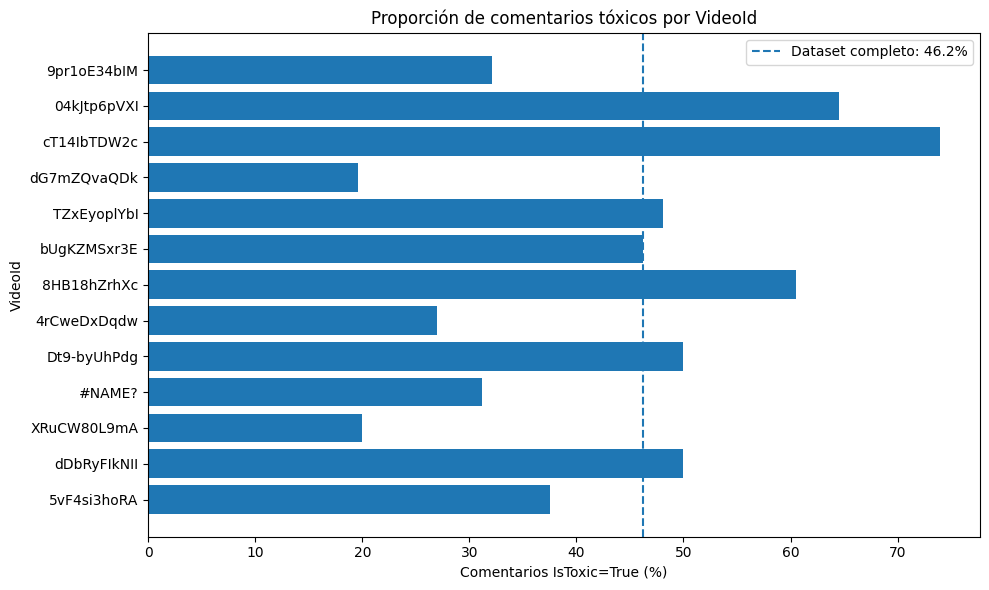

In [53]:
video_plot = toxicity_by_video.copy()

plt.figure(figsize=(10, 6))

plt.barh(
    video_plot["VideoId"][::-1],
    video_plot["porcentaje_toxicos"][::-1]
)

plt.axvline(
    df["IsToxic"].mean() * 100,
    linestyle="--",
    label=f"Dataset completo: {df['IsToxic'].mean() * 100:.1f}%"
)

plt.title("Proporción de comentarios tóxicos por VideoId")
plt.xlabel("Comentarios IsToxic=True (%)")
plt.ylabel("VideoId")
plt.legend()

plt.tight_layout()
plt.show()

Nota: los porcentajes deben interpretarse conjuntamente con el número de comentarios de cada vídeo. Una proporción elevada o reducida basada en pocos registros presenta mayor variabilidad y no es directamente comparable con la misma precisión a la de los vídeos con mayor representación.

#### Conclusión

La proporción global de comentarios con `IsToxic = True` es del 46,2 %, pero el gráfico muestra una variabilidad considerable entre los distintos `VideoId`.

Entre los vídeos con mayor número de observaciones existen diferencias especialmente relevantes. `cT14IbTDW2c` alcanza un 74,0 % de comentarios tóxicos y `04kJtp6pVXI` un 64,5 %, mientras que `dG7mZQvaQDk` presenta un 19,6 % y `9pr1oE34bIM` un 32,1 %. Otros vídeos se sitúan próximos al promedio global.

Estas diferencias confirman que la distribución de `IsToxic` no es homogénea entre los vídeos de la muestra. Sin embargo, los porcentajes deben interpretarse junto con el número de observaciones de cada `VideoId`, especialmente en los vídeos con pocos comentarios.

Este patrón refuerza la necesidad de considerar el vídeo de origen durante el diseño de la futura estrategia de partición y evaluación, evitando asumir que todos los comentarios constituyen observaciones completamente independientes de su contexto.

## 9. Principales hallazgos del EDA

El análisis exploratorio ha permitido caracterizar la estructura, calidad, distribución de etiquetas, contenido textual y agrupación por vídeo del dataset.

A continuación se resumen los principales resultados cuantitativos obtenidos. Estos hallazgos describen exclusivamente la muestra analizada y sirven como base para las decisiones posteriores de preprocesamiento, partición y modelado.

| Área | Hallazgo | Resultado |
|---|---|---:|
| Tamaño | Comentarios analizados | 1.000 |
| Estructura | Variables | 15 |
| Calidad | Valores ausentes | 0 |
| Calidad | Filas completamente duplicadas | 0 |
| Identificación | `CommentId` únicos | 1.000 |
| Texto | Textos distintos repetidos | 2 |
| Texto | Registros afectados por textos repetidos | 5 |
| Vídeos | `VideoId` distintos | 13 |
| Vídeos | Registros con `VideoId = "#NAME?"` | 16 |
| `IsToxic` | Positivos | 462 (46,2 %) |
| `IsToxic` | Negativos | 538 (53,8 %) |
| Etiquetas | Coincidencia entre `IsToxic` y presencia de alguna secundaria | 1.000/1.000 |
| Multietiqueta | `IsToxic=True` con 2 o más secundarias positivas | 362/462 (78,4 %) |
| Cobertura | `IsHomophobic` positivos | 0 |
| Cobertura | `IsRadicalism` positivos | 0 |
| Cobertura | `IsSexist` positivos | 1 |
| Texto | Mediana de longitud | 19 palabras |
| Texto | Media de longitud | 33,78 palabras |
| Texto | Rango observado | 1–815 palabras |
| Vocabulario | Tokens observados | 33.667 |
| Vocabulario | Términos únicos | 4.605 |
| Vocabulario | Términos que aparecen una sola vez | 2.517 (54,7 % del vocabulario) |
| Longitud vs. toxicidad | Mediana `IsToxic=False` | 18 palabras |
| Longitud vs. toxicidad | Mediana `IsToxic=True` | 20 palabras |
| Vídeos | Comentarios concentrados en los 3 vídeos principales | 592 (59,2 %) |
| Vídeos | Comentarios concentrados en los 5 vídeos principales | 808 (80,8 %) |
| Vídeos | Menor proporción de toxicidad entre vídeos con más de 100 comentarios | 19,6 % |
| Vídeos | Mayor proporción de toxicidad entre vídeos con más de 100 comentarios | 74,0 % |

### 9.1 Síntesis de los hallazgos

El dataset presenta una calidad estructural adecuada para continuar con las siguientes fases: no se detectaron valores ausentes ni filas completamente duplicadas y `CommentId` identifica de forma única los 1.000 registros. No obstante, se identificaron textos repetidos y un valor `VideoId = "#NAME?"` cuyo origen deberá verificarse antes de tomar una decisión definitiva de limpieza.

La etiqueta principal `IsToxic` presenta una distribución relativamente equilibrada, con un 46,2 % de casos positivos y un 53,8 % de negativos. En cambio, las etiquetas secundarias presentan una cobertura muy desigual, incluyendo categorías con muy pocos o ningún ejemplo positivo.

En los 1.000 registros se observa una correspondencia exacta entre `IsToxic` y la presencia de al menos una etiqueta secundaria positiva. Además, el 78,4 % de los comentarios tóxicos presenta dos o más etiquetas secundarias positivas, confirmando el carácter multietiqueta de la anotación disponible. Estas relaciones deberán considerarse especialmente para evitar posibles fugas de información durante el modelado.

El análisis textual muestra una distribución de longitud asimétrica y una diversidad léxica elevada. Más de la mitad de los términos únicos aparecen una sola vez. Los comentarios extremadamente cortos o largos no presentan evidencia suficiente para ser eliminados únicamente por su longitud.

La longitud tampoco muestra una separación clara entre comentarios tóxicos y no tóxicos: las medianas son de 20 y 18 palabras respectivamente y las distribuciones presentan un amplio solapamiento.

Finalmente, existe una fuerte estructura de agrupación por vídeo. Los cinco `VideoId` más representados concentran el 80,8 % de los comentarios y la proporción de `IsToxic` varía considerablemente entre vídeos. Esta dependencia deberá tenerse en cuenta al diseñar la estrategia de partición y evaluación.

### 9.1 Síntesis de los hallazgos

El dataset presenta una calidad estructural adecuada para continuar con las siguientes fases: no se detectaron valores ausentes ni filas completamente duplicadas y `CommentId` identifica de forma única los 1.000 registros. No obstante, se identificaron textos repetidos y un valor `VideoId = "#NAME?"` cuyo origen deberá verificarse antes de tomar una decisión definitiva de limpieza.

La etiqueta principal `IsToxic` presenta una distribución relativamente equilibrada, con un 46,2 % de casos positivos y un 53,8 % de negativos. En cambio, las etiquetas secundarias presentan una cobertura muy desigual, incluyendo categorías con muy pocos o ningún ejemplo positivo.

En los 1.000 registros se observa una correspondencia exacta entre `IsToxic` y la presencia de al menos una etiqueta secundaria positiva. Además, el 78,4 % de los comentarios tóxicos presenta dos o más etiquetas secundarias positivas, confirmando el carácter multietiqueta de la anotación disponible. Estas relaciones deberán considerarse especialmente para evitar posibles fugas de información durante el modelado.

El análisis textual muestra una distribución de longitud asimétrica y una diversidad léxica elevada. Más de la mitad de los términos únicos aparecen una sola vez. Los comentarios extremadamente cortos o largos no presentan evidencia suficiente para ser eliminados únicamente por su longitud.

La longitud tampoco muestra una separación clara entre comentarios tóxicos y no tóxicos: las medianas son de 20 y 18 palabras respectivamente y las distribuciones presentan un amplio solapamiento.

Finalmente, existe una fuerte estructura de agrupación por vídeo. Los cinco `VideoId` más representados concentran el 80,8 % de los comentarios y la proporción de `IsToxic` varía considerablemente entre vídeos. Esta dependencia deberá tenerse en cuenta al diseñar la estrategia de partición y evaluación.

## 10. Implicaciones para preprocesamiento y modelado

Los resultados del EDA permiten identificar aspectos que deberán considerarse al construir el pipeline de preparación de datos y evaluación del modelo.

Esta sección no aplica todavía transformaciones ni define decisiones definitivas. Su objetivo es traducir los hallazgos exploratorios en criterios que deberán validarse durante las siguientes fases del proyecto.

### 10.1 Calidad y preparación del texto

El dataset no presenta valores ausentes ni textos vacíos, por lo que no se requiere una estrategia específica de imputación para la variable `Text`.

Se detectaron espacios al inicio o al final de algunos comentarios, por lo que una normalización básica de espacios puede considerarse durante el preprocesamiento. Cualquier transformación adicional, como conversión a minúsculas, tratamiento de puntuación, URLs, menciones, caracteres especiales o stopwords, deberá justificarse según la representación textual y el modelo finalmente seleccionados.

Los comentarios presentan una variación importante de longitud, desde 1 hasta 815 palabras. La inspección realizada durante el EDA no aporta evidencia suficiente para eliminar automáticamente los textos muy cortos o muy largos. Si el modelo utilizado establece una longitud máxima de entrada, deberá analizarse posteriormente el efecto del truncamiento y la proporción de información afectada.

La elevada proporción de términos poco frecuentes tampoco justifica por sí sola su eliminación. El tratamiento del vocabulario dependerá de la estrategia de representación seleccionada.

### 10.2 Duplicados y textos repetidos

No se detectaron filas completamente duplicadas ni identificadores `CommentId` repetidos. Sin embargo, se identificaron 2 textos distintos repetidos que afectan a 5 registros.

Estos casos no se eliminan durante el EDA, ya que pueden representar comentarios reales publicados más de una vez.

Antes de realizar la partición de los datos deberá comprobarse que textos idénticos no queden distribuidos entre entrenamiento y evaluación de una forma que permita al modelo beneficiarse de ejemplos previamente observados.

### 10.3 Etiqueta objetivo y prevención de fuga de información

`IsToxic` presenta 462 casos positivos y 538 negativos, por lo que la clasificación binaria dispone de una representación relativamente equilibrada en esta muestra.

El EDA mostró además una correspondencia exacta entre `IsToxic` y la presencia de al menos una etiqueta secundaria positiva en los 1.000 registros.

Por este motivo, si el objetivo del modelo es estimar `IsToxic` a partir del contenido del comentario, las etiquetas secundarias no deberán utilizarse como variables predictoras cuando no estén disponibles en el escenario real de inferencia. Su utilización podría introducir fuga de información y producir métricas que no representen el funcionamiento real del sistema.

Las etiquetas secundarias pueden conservarse para análisis, evaluación complementaria o futuras extensiones multietiqueta, teniendo en cuenta que varias categorías presentan una cobertura positiva muy limitada o nula.

### 10.4 Estrategia de partición y evaluación

Los 1.000 comentarios están agrupados en únicamente 13 valores de `VideoId`, y los cinco vídeos con mayor representación concentran el 80,8 % de la muestra. Además, la proporción de `IsToxic` presenta diferencias importantes entre vídeos.

Una partición aleatoria exclusivamente a nivel de comentario podría colocar observaciones pertenecientes al mismo vídeo en entrenamiento y evaluación. Dado que estos comentarios pueden compartir contexto, temática y vocabulario, esto podría generar dependencia entre las particiones y producir una estimación excesivamente optimista de la capacidad de generalización.

Durante la fase de modelado deberá evaluarse una estrategia de partición basada en grupos de `VideoId` o una alternativa que controle explícitamente esta dependencia. También deberá comprobarse la distribución de `IsToxic` resultante, ya que el reducido número de vídeos y las diferencias entre ellos pueden dificultar simultáneamente la separación por grupos y el mantenimiento del balance de clases.

La estrategia definitiva deberá documentarse y justificarse antes del entrenamiento final.

### 10.5 Limitaciones para el modelado de etiquetas secundarias

La distribución de las etiquetas secundarias es considerablemente más desequilibrada que la de `IsToxic`.

`IsHomophobic` e `IsRadicalism` no presentan casos positivos en esta muestra, `IsSexist` dispone de un único positivo y otras categorías como `IsNationalist`, `IsReligiousHate` e `IsThreat` cuentan con muy pocos ejemplos.

Por tanto, el dataset actual no proporciona evidencia suficiente para entrenar y evaluar de forma fiable clasificadores independientes para todas las categorías secundarias.

Cualquier extensión futura hacia clasificación multietiqueta deberá considerar la disponibilidad de más datos, la cobertura de cada categoría y métricas adecuadas para clases minoritarias.

### 10.6 Tratamiento del valor `VideoId = "#NAME?"`

Se identificaron 16 registros con `VideoId = "#NAME?"`. Estos registros contienen `CommentId` y textos distintos, no presentan valores ausentes y muestran tanto comentarios tóxicos como no tóxicos.

El EDA no proporciona evidencia suficiente para determinar si este valor corresponde a un identificador válido, un error de exportación o una transformación previa del dataset.

Por tanto, no se elimina ni corrige automáticamente. Antes de utilizar `VideoId` para construir una partición definitiva por grupos deberá verificarse su procedencia si se dispone de información adicional sobre el dataset.

### 10.7 Implicaciones para el MVP

Los resultados del EDA permiten utilizar `IsToxic` como etiqueta observada para desarrollar y evaluar posteriormente un modelo de clasificación de toxicidad. Sin embargo, la salida de dicho modelo no deberá interpretarse automáticamente como una decisión de moderación.

El MVP está orientado al triaje asistido de comentarios. Por tanto, además de las métricas predictivas, las siguientes fases deberán considerar cómo transformar las salidas del modelo en señales útiles para priorización, incorporando posteriormente criterios de riesgo e incertidumbre y manteniendo la decisión final bajo control humano.

El dataset actual tampoco contiene una etiqueta específica de contenido violento. En consecuencia, cualquier funcionalidad relacionada con este fenómeno requerirá una definición operacional y evidencia adicional antes de poder evaluarse de forma independiente.

### 10.8 Decisiones a validar en las siguientes fases

| Aspecto | Evidencia del EDA | Decisión pendiente |
|---|---|---|
| Normalización textual | Existen espacios y variabilidad léxica | Definir transformaciones según el modelo |
| Longitud | 1–815 palabras | Evaluar longitud máxima y posible truncamiento |
| Textos repetidos | 5 registros afectados | Controlar su distribución entre particiones |
| Variable objetivo | `IsToxic` relativamente equilibrada | Definir formalmente el objetivo de clasificación |
| Etiquetas secundarias | Correspondencia exacta con `IsToxic` | Evitar fuga de información y definir su posible uso auxiliar |
| Partición | Solo 13 `VideoId`; top 5 = 80,8 % | Comparar estrategias considerando grupos |
| Categorías minoritarias | Varias etiquetas con muy pocos positivos | Limitar alcance o conseguir más datos |
| `#NAME?` | 16 registros | Verificar procedencia antes del split definitivo |
| Representación textual | Vocabulario amplio y diverso | Seleccionar representación/modelo |
| Evaluación | Dependencia por vídeo y clases secundarias desbalanceadas | Definir métricas y protocolo de evaluación |

## 11. Conclusiones del EDA

El análisis exploratorio ha permitido caracterizar el dataset de 1.000 comentarios y establecer una base para las siguientes fases del proyecto. La muestra contiene 15 variables, incluyendo el texto, identificadores de comentario y vídeo, una etiqueta principal `IsToxic` y 11 etiquetas secundarias relacionadas con distintas categorías de toxicidad.

Desde el punto de vista de calidad estructural, no se detectaron valores ausentes, textos vacíos, filas completamente duplicadas ni identificadores `CommentId` repetidos. Se identificaron 2 textos distintos repetidos que afectan a 5 registros y un valor `VideoId = "#NAME?"` presente en 16 observaciones. Ninguno de estos casos presenta evidencia suficiente para justificar su eliminación automática durante el EDA.

La etiqueta `IsToxic` presenta una distribución relativamente equilibrada, con 462 comentarios positivos (46,2 %) y 538 negativos (53,8 %). Sin embargo, las etiquetas secundarias muestran una representación muy desigual. Algunas categorías cuentan con muy pocos ejemplos positivos y `IsHomophobic` e `IsRadicalism` no presentan positivos en esta muestra, lo que limita su posible entrenamiento y evaluación independiente.

Se observó una correspondencia exacta, en los 1.000 registros, entre `IsToxic` y la presencia de al menos una etiqueta secundaria positiva. Además, el 78,4 % de los comentarios `IsToxic = True` presenta dos o más etiquetas secundarias positivas. Estos resultados confirman una estructura multietiqueta relevante y hacen necesario evitar el uso inadecuado de estas etiquetas como predictores de `IsToxic` cuando no estén disponibles en inferencia, ya que podría introducirse fuga de información.

El análisis del texto muestra una elevada variabilidad de longitud y vocabulario. Los comentarios contienen entre 1 y 815 palabras, con una mediana de 19, y el corpus analizado contiene 33.667 tokens y 4.605 términos únicos. El 54,7 % del vocabulario aparece una sola vez. Los comentarios extremadamente cortos o largos pueden contener información válida, por lo que no existe evidencia para eliminarlos únicamente por su longitud.

La comparación entre `IsToxic = True` e `IsToxic = False` tampoco muestra una separación clara basada exclusivamente en la longitud. Las medianas son de 20 y 18 palabras respectivamente y las distribuciones presentan un amplio solapamiento. Por tanto, la longitud puede estudiarse posteriormente como una característica auxiliar, pero el EDA no aporta evidencia para utilizarla aisladamente como indicador de toxicidad.

La estructura por vídeo constituye uno de los principales aspectos a considerar en la evaluación. Los 1.000 comentarios proceden de solo 13 valores de `VideoId`, y los cinco vídeos con mayor representación concentran el 80,8 % de la muestra. Además, la proporción de `IsToxic` varía considerablemente entre vídeos. Esta agrupación introduce una posible dependencia contextual entre comentarios del mismo vídeo que deberá controlarse al definir las particiones de entrenamiento, validación y test.

En conjunto, el dataset proporciona una base utilizable para desarrollar un primer modelo orientado a la clasificación binaria de `IsToxic`, siempre dentro de las limitaciones identificadas. Los resultados obtenidos describen esta muestra concreta y no demuestran que sea representativa de los comentarios de YouTube en general.

Las siguientes fases deberán definir y validar el preprocesamiento textual, controlar textos repetidos, investigar el valor `VideoId = "#NAME?"`, diseñar una estrategia de partición que considere la agrupación por vídeo y establecer un protocolo de evaluación adecuado antes del entrenamiento final.

Finalmente, `IsToxic` debe entenderse como una etiqueta observada del dataset y no como una decisión automática de moderación. El objetivo del MVP es utilizar posteriormente las salidas del modelo como apoyo para el triaje y priorización de comentarios, incorporando criterios de riesgo e incertidumbre y manteniendo la decisión final bajo control humano. El dataset tampoco dispone de una etiqueta específica de contenido violento, por lo que este fenómeno no puede evaluarse directamente con la evidencia disponible.